Análisis exploratorio de datos de la energía solar
grupo J 
BOOTCAMP TALENTO TECH


In [1]:
#cargamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np


In [12]:
#Cargamos los datos, fuente Kaggle
df = pd.read_excel(r'C:\\Users\\ANGELA MARIA\\Downloads\\analisis_datos_2026\\energia_solar\\data.xlsx', 
                    sheet_name='solar_weather')
#CARGAMOS EL DICCIONARIO DE VARIABLE
dic = pd.read_excel(r'C:\\Users\\ANGELA MARIA\\Downloads\\analisis_datos_2026\\energia_solar\\data.xlsx', 
                    sheet_name='solar_weather (2)', header =None)

In [13]:
#vamos a crear el diccionario de las variables con la primera 
# fila del data set quye tiene el nombre de las variables y la descripción de cada variable
dic = dic.iloc[0]
print(dic)


0                           Time - YYYY-MM-DD HH:MM:SS.
1     Energy delta[Wh] - The difference in energy co...
2     GHI (W/m²) - Global Horizontal Irradiance in W...
3     temp (°C) - The temperature in degrees Celsius...
4     pressure (hPa) -The atmospheric pressure in he...
5     humidity (%) The relative humidity in percenta...
6     wind_speed (m/s) -The wind speed in meters per...
7     rain_1h (mm) -The amount of precipitation in m...
8       snow_1h - The amount of snowfall in millimeters
9                      clouds_all - The cloud situation
10                                                isSun
11                                         sunlightTime
12                                            dayLength
13                               SunlightTime/daylength
14                                         weather_type
15                                                 hour
16                                                month
Name: 0, dtype: object


In [14]:
#EDa
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Time                    196776 non-null  datetime64[ns]
 1   Energy delta[Wh]        196776 non-null  int64         
 2   GHI                     196776 non-null  float64       
 3   temp                    196776 non-null  float64       
 4   pressure                196776 non-null  int64         
 5   humidity                196776 non-null  int64         
 6   wind_speed              196776 non-null  float64       
 7   rain_1h                 196776 non-null  float64       
 8   snow_1h                 196776 non-null  float64       
 9   clouds_all              196776 non-null  int64         
 10  isSun                   196776 non-null  int64         
 11  sunlightTime            196776 non-null  int64         
 12  dayLength               196776

In [ ]:
print(df.describe())
#se sospecha una distibución con cola a la izquierda en la mayoría de las variables, 
# por lo tanto se va a hacer un análisis de la distribución de cada variable para confirmar esta sospecha.

                                Time  Energy delta[Wh]            GHI  \
count                         196776     196776.000000  196776.000000   
mean   2019-10-29 22:44:12.085620992        573.008228      32.596538   
min              2017-01-01 00:00:00          0.000000       0.000000   
25%              2018-06-02 10:26:15          0.000000       0.000000   
50%              2019-10-28 20:52:30          0.000000       1.600000   
75%              2021-03-24 07:18:45        577.000000      46.800000   
max              2022-08-31 17:45:00       5020.000000     229.200000   
std                              NaN       1044.824047      52.172018   

                temp       pressure       humidity     wind_speed  \
count  196776.000000  196776.000000  196776.000000  196776.000000   
mean        9.790521    1015.292780      79.810566       3.937746   
min       -16.600000     977.000000      22.000000       0.000000   
25%         3.600000    1010.000000      70.000000       2.600000 

In [16]:
df.shape

(196776, 17)

In [ ]:
# Da el valor de los nulos en %
df.isnull().sum() / len(df) * 100
#se concluye que no hay datos nulos en el dataset, por lo tanto no es necesario hacer un tratamiento de los datos nulos.

Time                      0.0
Energy delta[Wh]          0.0
GHI                       0.0
temp                      0.0
pressure                  0.0
humidity                  0.0
wind_speed                0.0
rain_1h                   0.0
snow_1h                   0.0
clouds_all                0.0
isSun                     0.0
sunlightTime              0.0
dayLength                 0.0
SunlightTime/daylength    0.0
weather_type              0.0
hour                      0.0
month                     0.0
dtype: float64

In [ ]:
#vamos a ver cuantos de nuestros registros son iguales a cero en porcentaje
(df == 0).sum() / len(df) * 100


Time                       0.000000
Energy delta[Wh]          51.251169
GHI                       48.300606
temp                       0.530553
pressure                   0.000000
humidity                   0.000000
wind_speed                 0.004066
rain_1h                   87.311461
snow_1h                   98.099362
clouds_all                 6.659349
isSun                     48.003822
sunlightTime              48.003822
dayLength                  0.000000
SunlightTime/daylength    48.003822
weather_type               0.000000
hour                       4.167175
month                      0.000000
dtype: float64

array([[<Axes: title={'center': 'Time'}>,
        <Axes: title={'center': 'Energy delta[Wh]'}>,
        <Axes: title={'center': 'GHI'}>,
        <Axes: title={'center': 'temp'}>],
       [<Axes: title={'center': 'pressure'}>,
        <Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'wind_speed'}>,
        <Axes: title={'center': 'rain_1h'}>],
       [<Axes: title={'center': 'snow_1h'}>,
        <Axes: title={'center': 'clouds_all'}>,
        <Axes: title={'center': 'isSun'}>,
        <Axes: title={'center': 'sunlightTime'}>],
       [<Axes: title={'center': 'dayLength'}>,
        <Axes: title={'center': 'SunlightTime/daylength'}>,
        <Axes: title={'center': 'weather_type'}>,
        <Axes: title={'center': 'hour'}>],
       [<Axes: title={'center': 'month'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

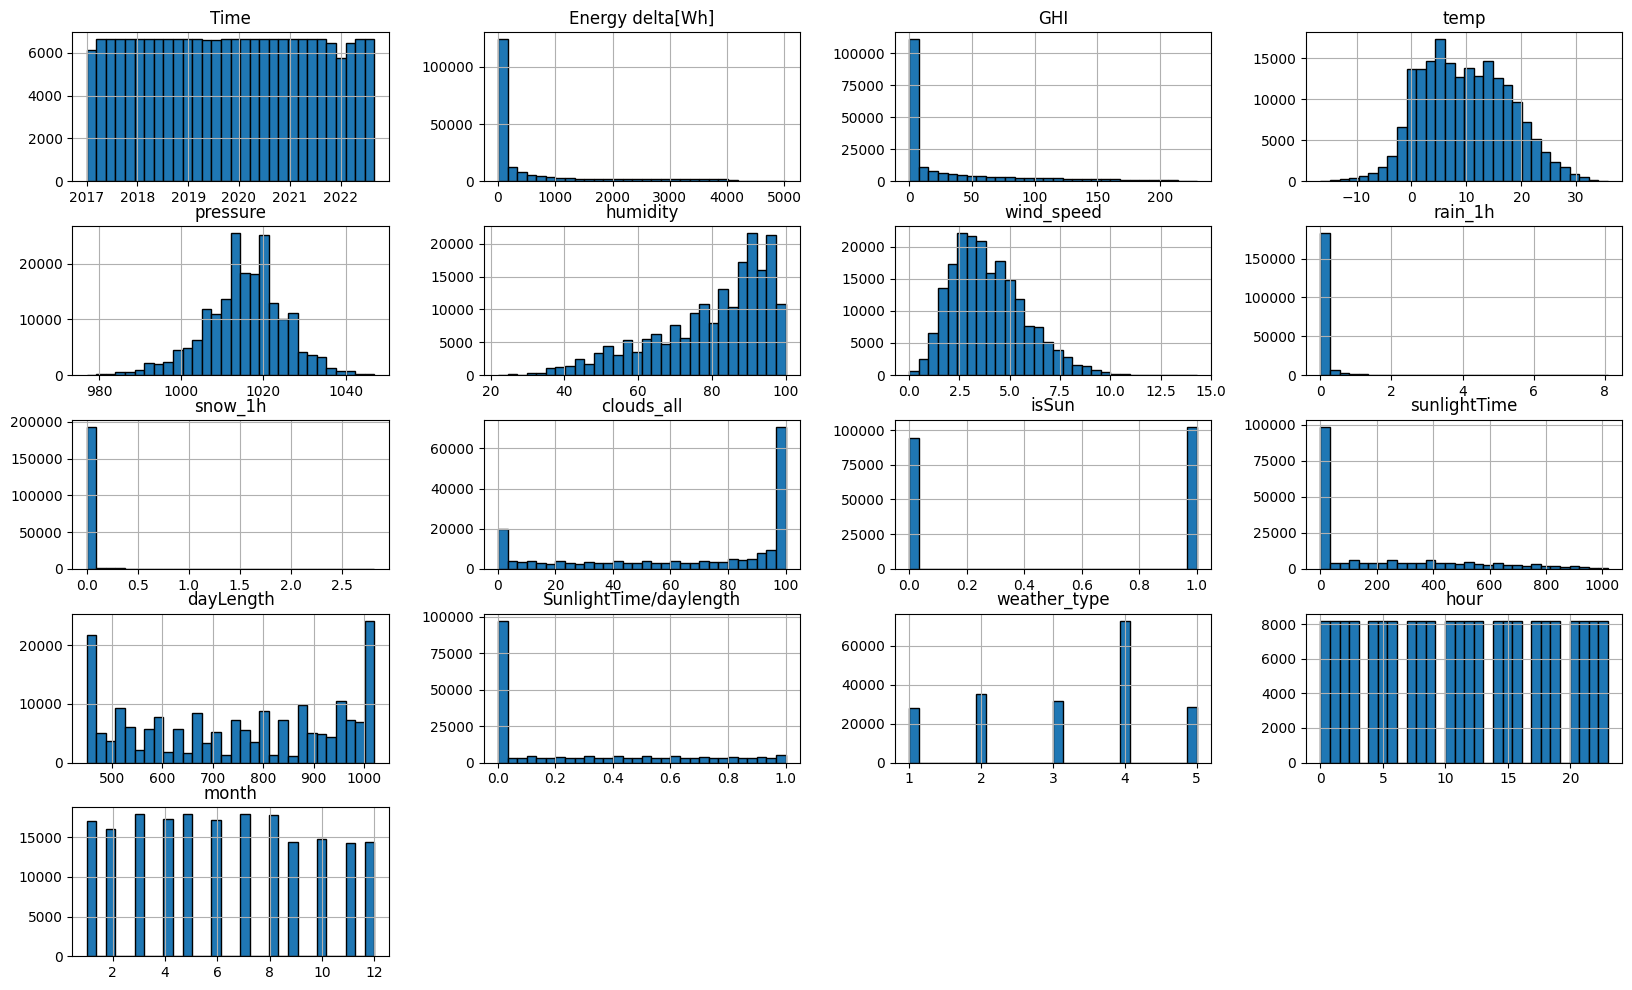

In [28]:
#Ahora las distribuciones de cada variable
df.hist(bins=30, figsize=(20,12), edgecolor="black")

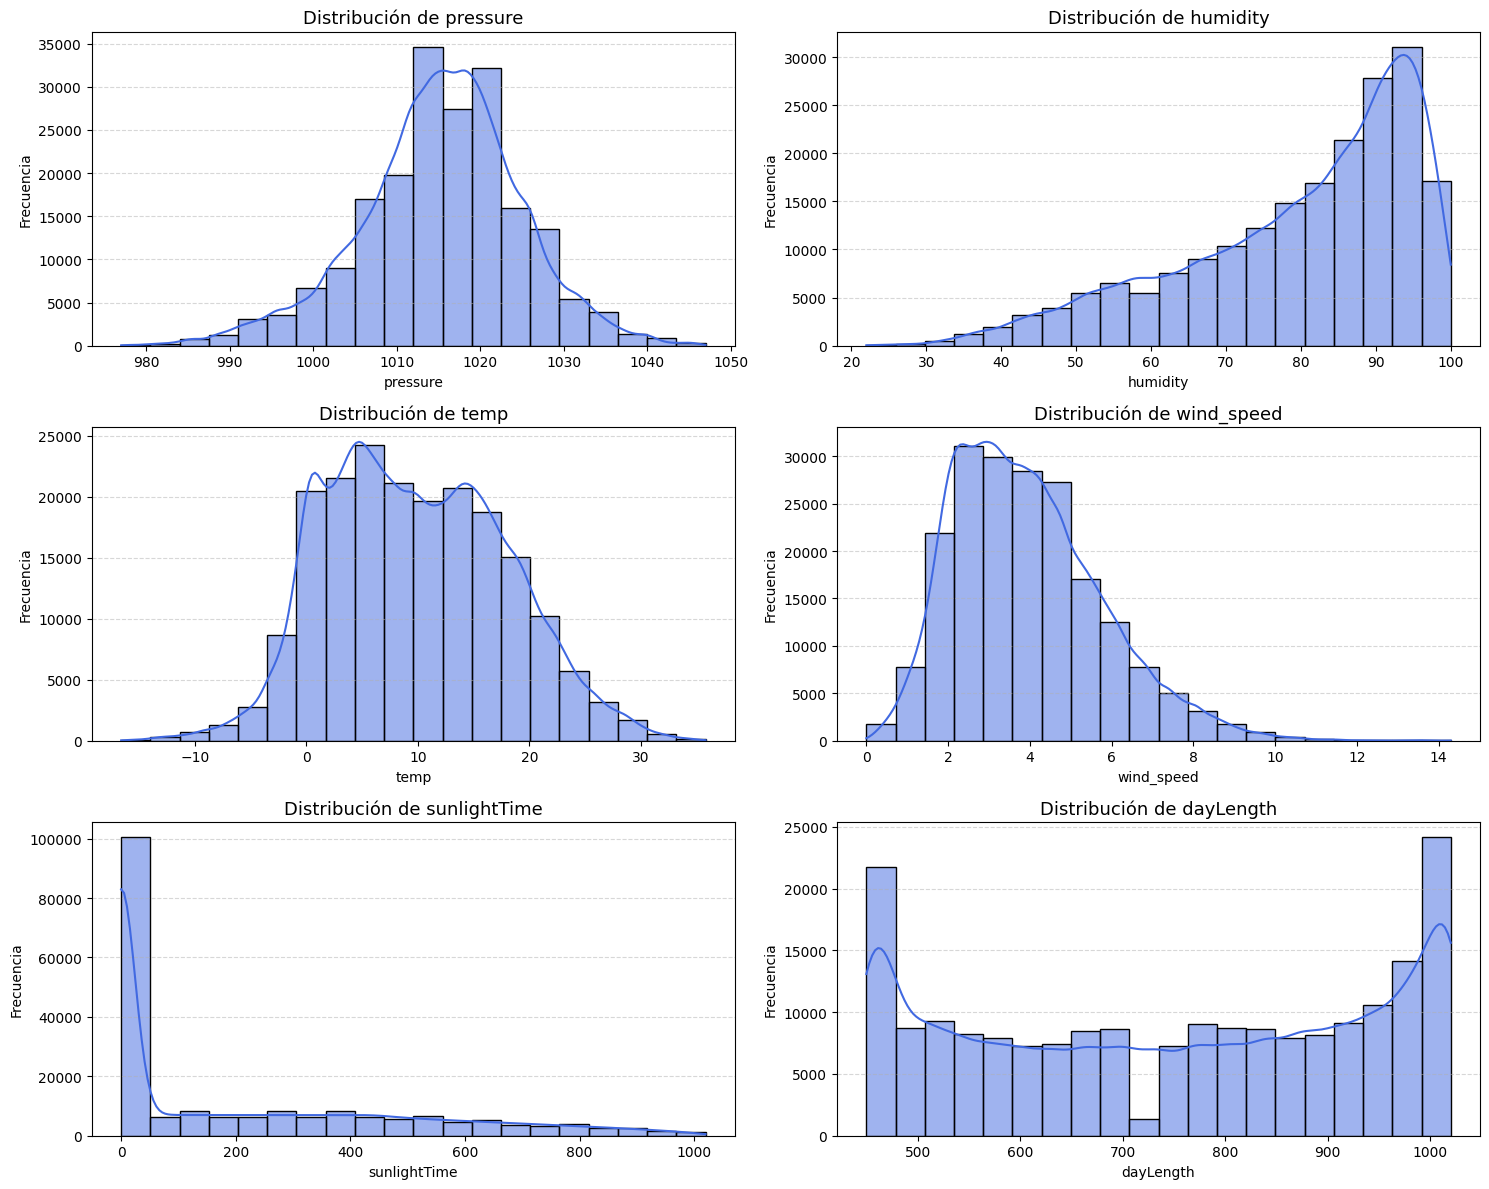

In [32]:
# 1. Lista de variables (está bien como la tienes)
numerical_features = ['pressure', 'humidity', 'temp', 'wind_speed', 'sunlightTime', 'dayLength']

# 2. Configurar el tamaño de la figura total
plt.figure(figsize=(15, 12)) 

for i, feature in enumerate(numerical_features):
    # CAMBIO: Ahora usamos 3 filas y 2 columnas para que quepan las 6 gráficas
    plt.subplot(3, 2, i + 1) 
    
    # Graficar con Seaborn
    # kde=True añade la línea de densidad (la curva suave)
    sns.histplot(df[feature], kde=True, bins=20, color='royalblue', edgecolor='black')
    
    # Estética
    plt.title(f'Distribución de {feature}', fontsize=13)
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# 3. Ajustar espacio entre gráficas para que no se encimen los textos
plt.tight_layout()
plt.show()

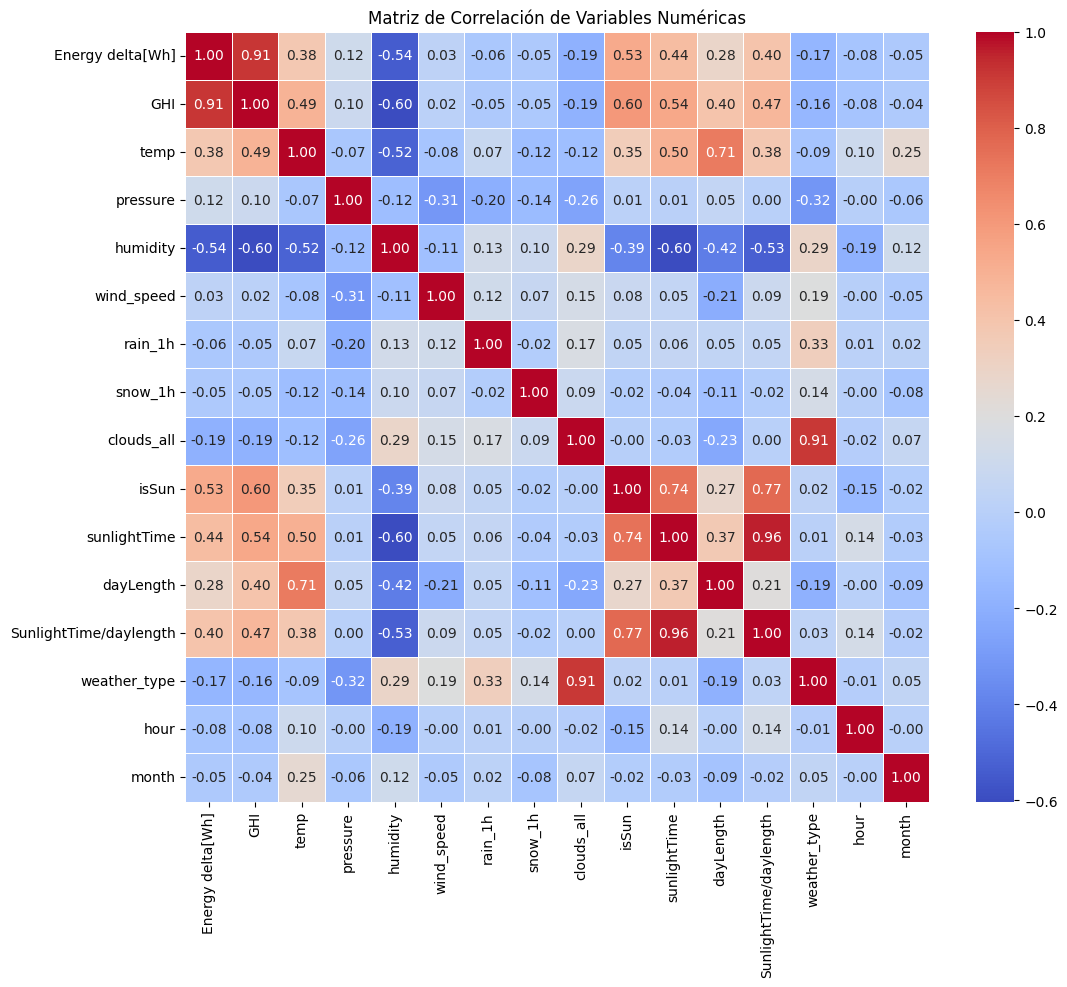

In [33]:
#mapa de calor correlaciones
# Seleccionar solo las columnas numéricas (excluyendo 'user_id' ya que es solo un identificador)
numerical_cols_for_corr = df.select_dtypes(include=['number']).columns

# Calcular la matriz de correlación
correlation_matrix = df[numerical_cols_for_corr].corr()

# Crear un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

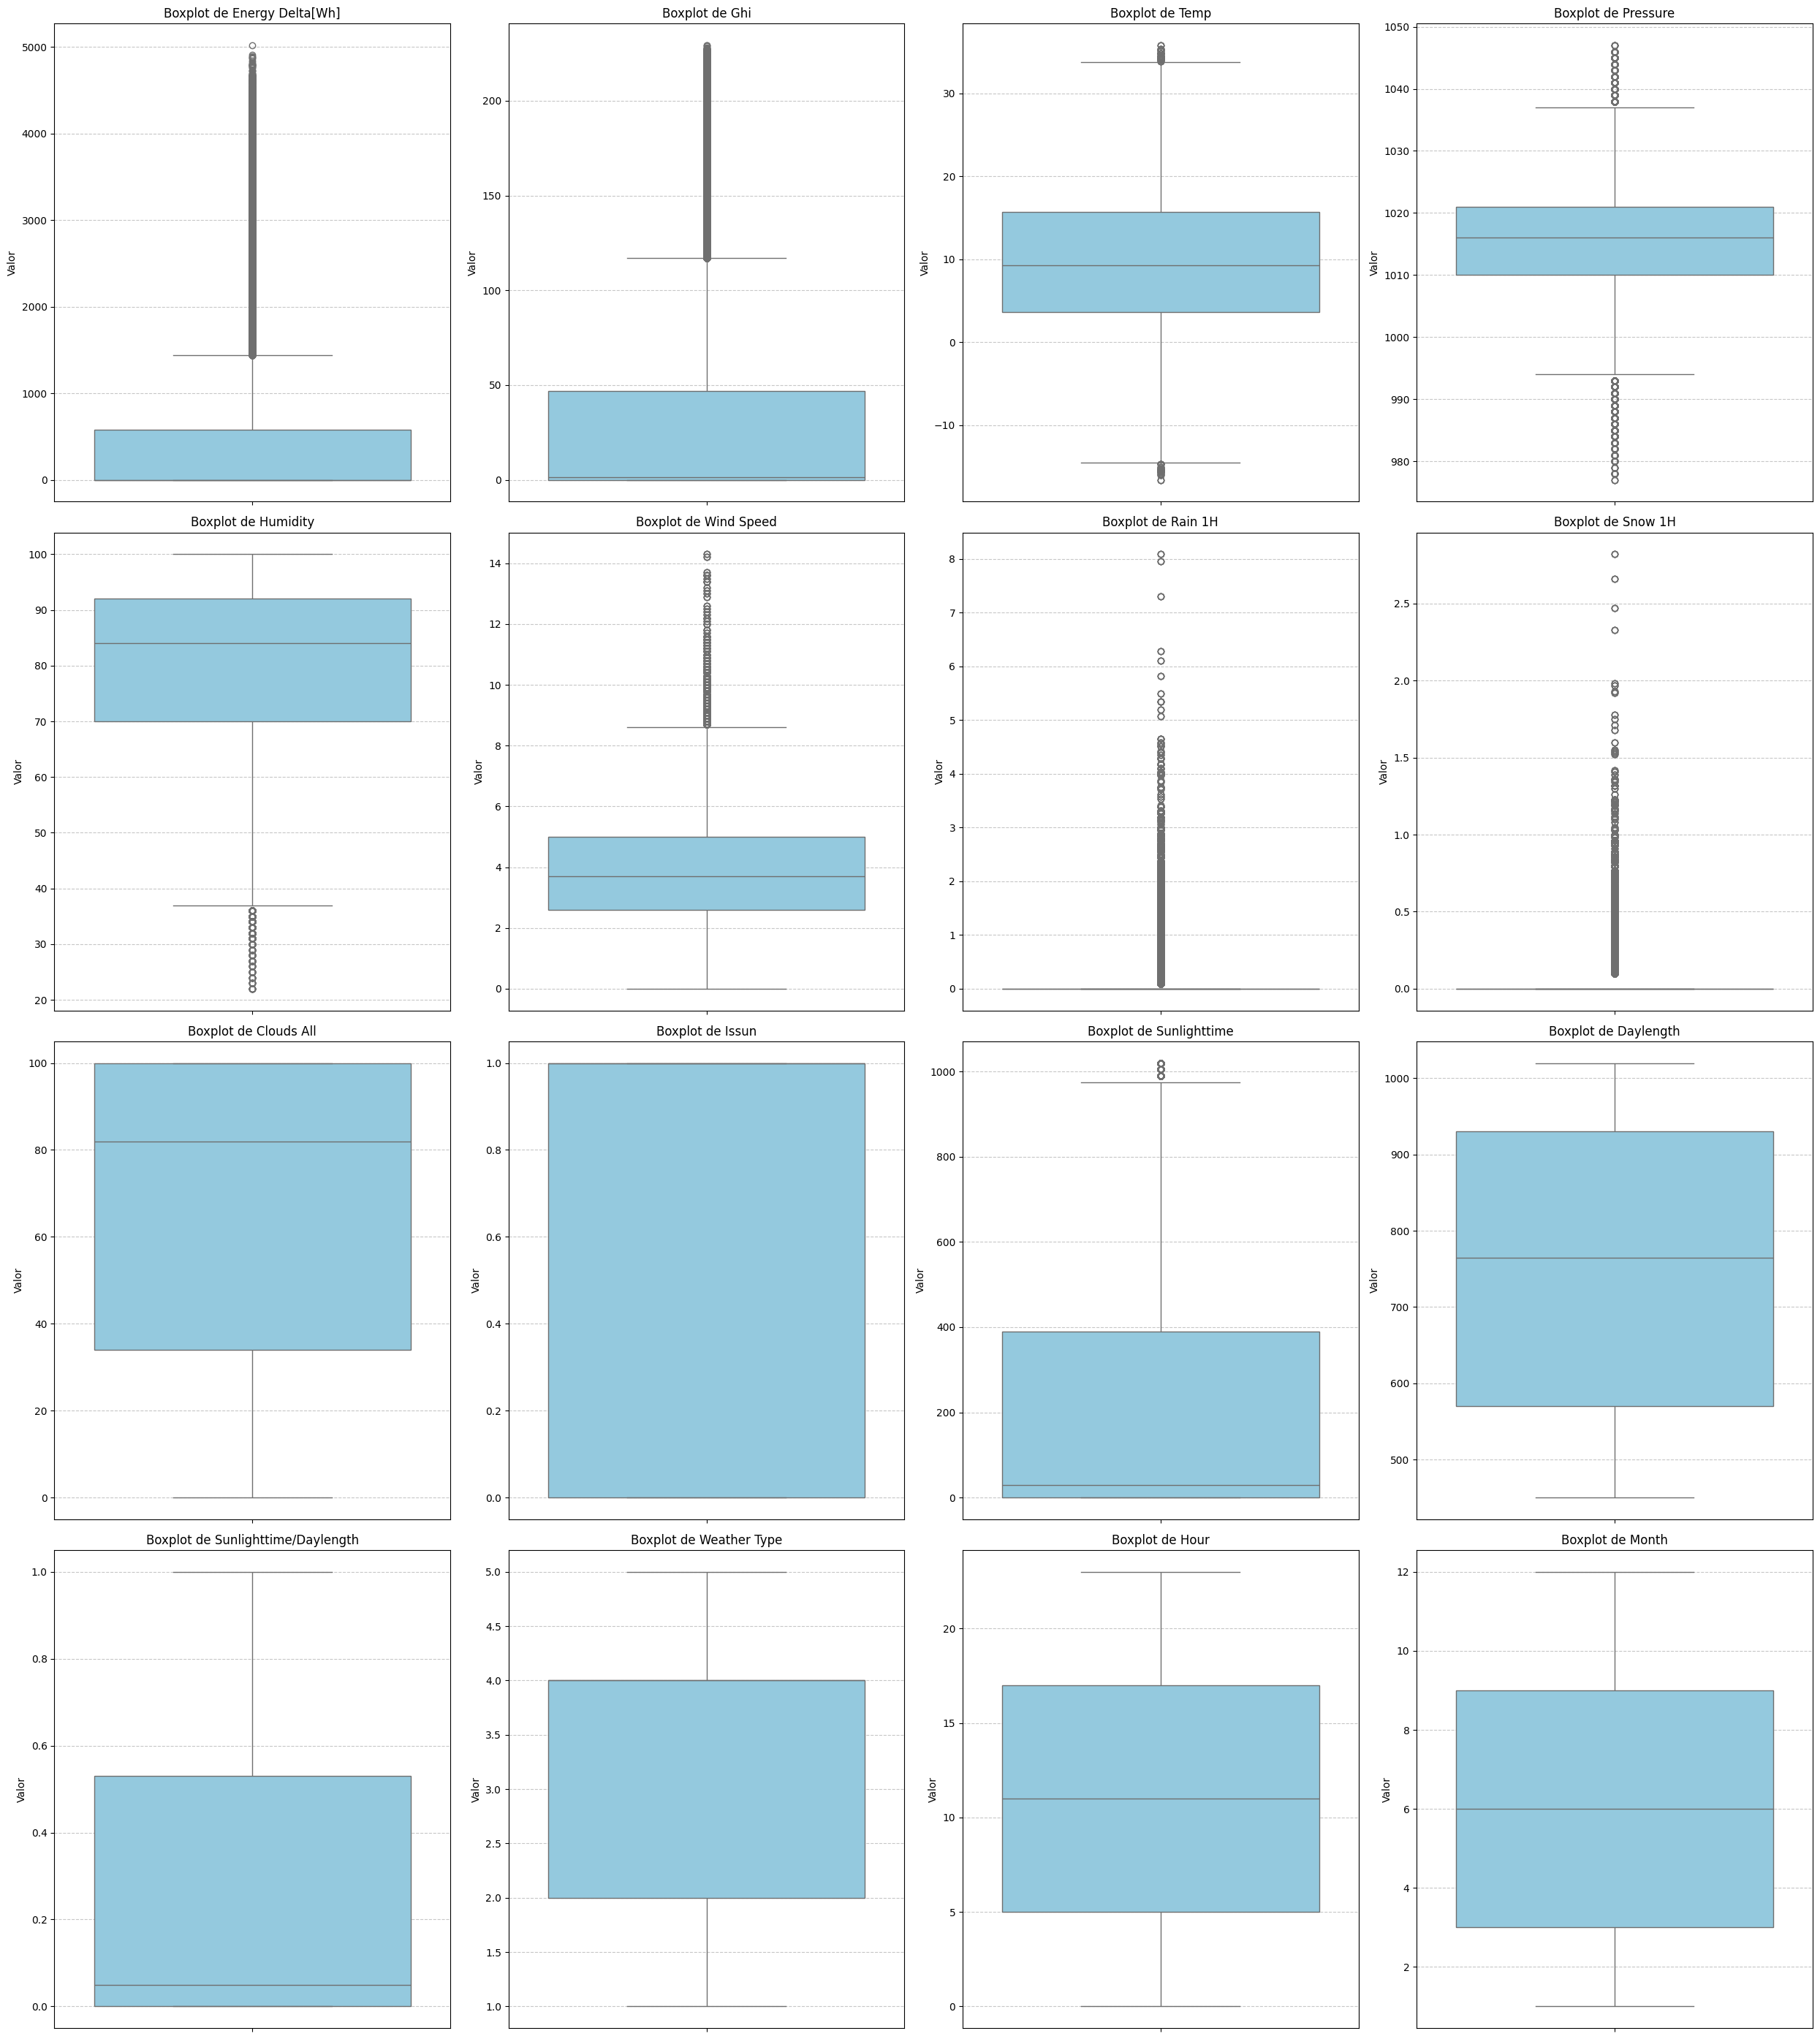

In [40]:
# Seleccionar las columnas numéricas relevantes del DataFrame para el boxplot
# Excluimos 'user_id' ya que es un identificador y no una medida a analizar con boxplot
numerical_cols_for_boxplot = df.select_dtypes(include=np.number).columns

# Crear un boxplot para cada columna numérica individualmente
plt.figure(figsize=(25, 28))
for i, col in enumerate(numerical_cols_for_boxplot):
    plt.subplot(4, 4, i + 1) # Ajusta la cuadrícula según el número de variables (ej. 2 filas, 4 columnas)
    sns.boxplot(y=df[col], showfliers=True, color='skyblue') # showfliers=True para mostrar los atípicos
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.ylabel('Valor')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()